# Experiment 1 — Full-parameter GRPO

16 questions × 16 responses per rollout

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "results").is_dir() else Path.cwd().parent
FIGURES = ROOT / "results" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.style.use("seaborn-v0_8-whitegrid")

def read_results(experiment):
    files = sorted((ROOT / "results" / experiment).glob("*.json"))
    return [json.loads(path.read_text()) for path in files]

rows = read_results("01_grpo")
summary = pd.DataFrame([{
    "seed": row["config"]["seed"], "initial": row["eval"][0]["reward"],
    "final": row["eval"][-1]["reward"], "format_rate": row["eval"][-1]["format_reward"],
    "minutes": row["elapsed_seconds"] / 60,
} for row in rows]).sort_values("seed")
summary.style.format({"initial": "{:.2%}", "final": "{:.2%}", "format_rate": "{:.2%}", "minutes": "{:.1f}"})

,seed,initial,final,format_rate,minutes
0,0,17.19%,35.94%,75.39%,22.7
1,1,14.84%,35.16%,83.20%,22.8
2,2,14.84%,32.03%,76.56%,24.4


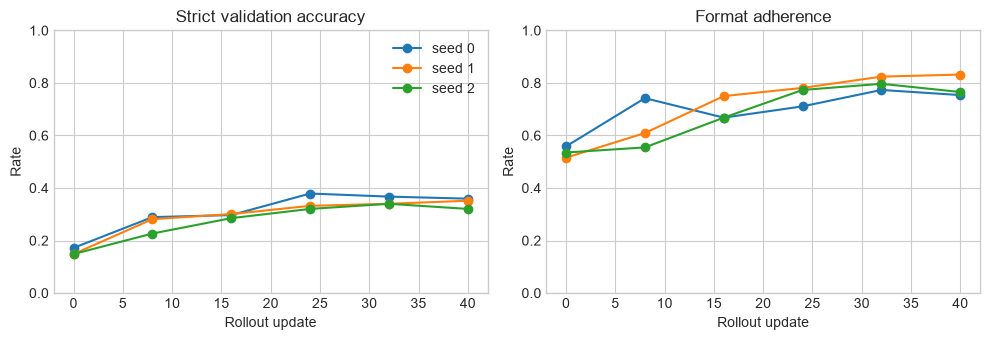

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True)
for row in rows:
    curve = pd.DataFrame(row["eval"])
    label = f"seed {row['config']['seed']}"
    axes[0].plot(curve.rollout_step, curve.reward, marker="o", label=label)
    axes[1].plot(curve.rollout_step, curve.format_reward, marker="o", label=label)
for axis, title in zip(axes, ["Strict validation accuracy", "Format adherence"]):
    axis.set(title=title, xlabel="Rollout update", ylabel="Rate"); axis.set_ylim(0, 1)
axes[0].legend(); fig.tight_layout()
# fig.savefig(FIGURES / "01_full_grpo.png", dpi=180, bbox_inches="tight")